# Problem Statement

**Objective:**  
AeroFit, a leading brand in fitness equipment, aims to optimize its marketing strategies and product recommendations by developing detailed customer profiles for its treadmill models (KP281, KP481, KP781). The goal is to understand the characteristics of customers who purchase each treadmill model and determine if demographic or behavioral factors influence product choice.

**Key Questions:**

- What are the overall purchasing trends across the three treadmill models?
- Do demographic factors (e.g., Age, Gender, Marital Status) influence the choice of treadmill?
- What is the marginal probability of a customer purchasing each product, and how does this change when conditioned on factors such as Gender or Marital Status?
- Are there significant correlations among customer attributes (e.g., Age, Income, Usage, Fitness, Miles) that can provide further insights for customer segmentation and targeted marketing?

**Scope of Analysis:**

- **Data Overview:**  
  The dataset includes customer information such as:
  - **Product:** Treadmill model purchased (KP281, KP481, or KP781)
  - **Age:** Customer's age in years
  - **Gender:** Male or Female
  - **Education:** Years of education
  - **MaritalStatus:** Single or Partnered
  - **Usage:** Average number of times the treadmill is used per week
  - **Fitness:** Self-rated fitness on a scale from 1 (poor) to 5 (excellent)
  - **Income:** Annual income (in $)
  - **Miles:** Average number of miles expected to be walked/run per week

- **Analysis Objectives:**
  - **Descriptive Analysis:**  
    Examine the overall distributions and basic metrics of the dataset.
  - **Marginal & Conditional Probabilities:**  
    Compute the marginal probability of purchasing each product and the conditional probabilities given demographic factors.
  - **Correlation Analysis:**  
    Explore the relationships among different numerical features.
  - **Customer Profiling:**  
    Segment the customer base to tailor marketing strategies and product enhancements.

By addressing these questions, AeroFit will gain a deeper understanding of its customer base, enabling the development of targeted marketing campaigns and informed product development decisions.


In [1]:
import pandas as pd 
import numpy as np 

In [2]:
df= pd.read_csv('aerofit_treadmill.csv')

In [3]:
df.head()

,Product,Age,Gender,Education,MaritalStatus,Usage,Fitness,Income,Miles
0,KP281,18,Male,14,Single,3,4,29562,112
1,KP281,19,Male,15,Single,2,3,31836,75
2,KP281,19,Female,14,Partnered,4,3,30699,66
3,KP281,19,Male,12,Single,3,3,32973,85
4,KP281,20,Male,13,Partnered,4,2,35247,47


In [31]:
df.shape

(180, 10)

In [4]:
print("\nDataset Info:")
print(df.info())


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180 entries, 0 to 179
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Product        180 non-null    object
 1   Age            180 non-null    int64 
 2   Gender         180 non-null    object
 3   Education      180 non-null    int64 
 4   MaritalStatus  180 non-null    object
 5   Usage          180 non-null    int64 
 6   Fitness        180 non-null    int64 
 7   Income         180 non-null    int64 
 8   Miles          180 non-null    int64 
dtypes: int64(6), object(3)
memory usage: 12.8+ KB
None


In [7]:
print("\nSummary Statistics for Numerical Columns:")
print(df.describe())


Summary Statistics for Numerical Columns:
              Age   Education       Usage     Fitness         Income  \
count  180.000000  180.000000  180.000000  180.000000     180.000000   
mean    28.788889   15.572222    3.455556    3.311111   53719.577778   
std      6.943498    1.617055    1.084797    0.958869   16506.684226   
min     18.000000   12.000000    2.000000    1.000000   29562.000000   
25%     24.000000   14.000000    3.000000    3.000000   44058.750000   
50%     26.000000   16.000000    3.000000    3.000000   50596.500000   
75%     33.000000   16.000000    4.000000    4.000000   58668.000000   
max     50.000000   21.000000    7.000000    5.000000  104581.000000   

            Miles  
count  180.000000  
mean   103.194444  
std     51.863605  
min     21.000000  
25%     66.000000  
50%     94.000000  
75%    114.750000  
max    360.000000  


In [15]:
print("\nValue counts for 'Product Purchased':")
print(df['Product'].value_counts())


Value counts for 'Product Purchased':
KP281    80
KP481    60
KP781    40
Name: Product, dtype: int64


In [8]:
print("\nValue counts for 'Gender':")
print(df['Gender'].value_counts())


Value counts for 'Gender':
Male      104
Female     76
Name: Gender, dtype: int64


In [9]:
print("\nValue counts for 'MaritalStatus':")
print(df['MaritalStatus'].value_counts())


Value counts for 'MaritalStatus':
Partnered    107
Single        73
Name: MaritalStatus, dtype: int64


In [10]:
print("\nMissing values per column:")
print(df.isnull().sum())


Missing values per column:
Product          0
Age              0
Gender           0
Education        0
MaritalStatus    0
Usage            0
Fitness          0
Income           0
Miles            0
dtype: int64


In [11]:
print("\nData types of each column:")
print(df.dtypes)


Data types of each column:
Product          object
Age               int64
Gender           object
Education         int64
MaritalStatus    object
Usage             int64
Fitness           int64
Income            int64
Miles             int64
dtype: object



## Data Overview
- **Dataset Size:**  
  - **180 records** and **9 columns** representing customer details.
- **Columns:**  
  - **Product:** Treadmill model purchased (KP281, KP481, KP781)
  - **Age:** Customer's age (18 to 50 years)
  - **Gender:** Male or Female
  - **Education:** Years of education
  - **MaritalStatus:** Single or Partnered
  - **Usage:** Expected number of treadmill uses per week
  - **Fitness:** Self-rated fitness level (1 to 5 scale)
  - **Income:** Annual income in dollars
  - **Miles:** Expected weekly miles

## Key Descriptive Statistics
- **Age:**  
  - Average age is **~28.8 years** with a range from **18 to 50 years**.
- **Education:**  
  - Customers have an average of **15.6 years** of education, suggesting a well-educated customer base.
- **Usage:**  
  - On average, customers plan to use their treadmill **3.46 times per week**.
- **Fitness:**  
  - The average fitness rating is **3.31** on a 1-to-5 scale.
- **Income:**  
  - The average annual income is **~$53,720**, ranging from **$29,562 to $104,581**.
- **Miles:**  
  - Customers expect to cover around **103 miles per week**, though this varies significantly (range: 21 to 360 miles).

## Distribution of Categorical Variables
- **Product Distribution:**
  - **KP281:** 80 customers
  - **KP481:** 60 customers
  - **KP781:** 40 customers
- **Gender Distribution:**
  - **Male:** 104 customers
  - **Female:** 76 customers
- **Marital Status:**
  - **Partnered:** 107 customers
  - **Single:** 73 customers

## Implications for Stakeholders
- **Targeted Marketing:**
  - **Product-Specific Strategies:**  
    KP281 is the most popular model, which might appeal more to first-time buyers or budget-conscious customers. Tailoring messaging around affordability and ease of use could enhance KP281 sales.
  - **Gender-Focused Campaigns:**  
    With a higher proportion of male customers (58%), consider gender-targeted advertisements or promotions. However, a strong female customer base (42%) also suggests a need for inclusive campaigns.
  
- **Customer Segmentation:**
  - **Age & Education:**  
    The average customer is in their late 20s and well-educated. Digital and social media channels are likely to be effective, with messaging that emphasizes technology and efficiency.
  - **Usage and Fitness Patterns:**  
    Variations in usage and self-rated fitness indicate that our customer base includes both casual users and fitness enthusiasts. This insight can help tailor post-purchase support and additional service offerings.
  
- **Income and Affordability:**
  - The broad income range suggests opportunities for differentiated pricing strategies. Premium models like KP781 might be marketed with advanced features to high-income, fitness-conscious segments, while KP281 can be positioned as an affordable entry-level option.



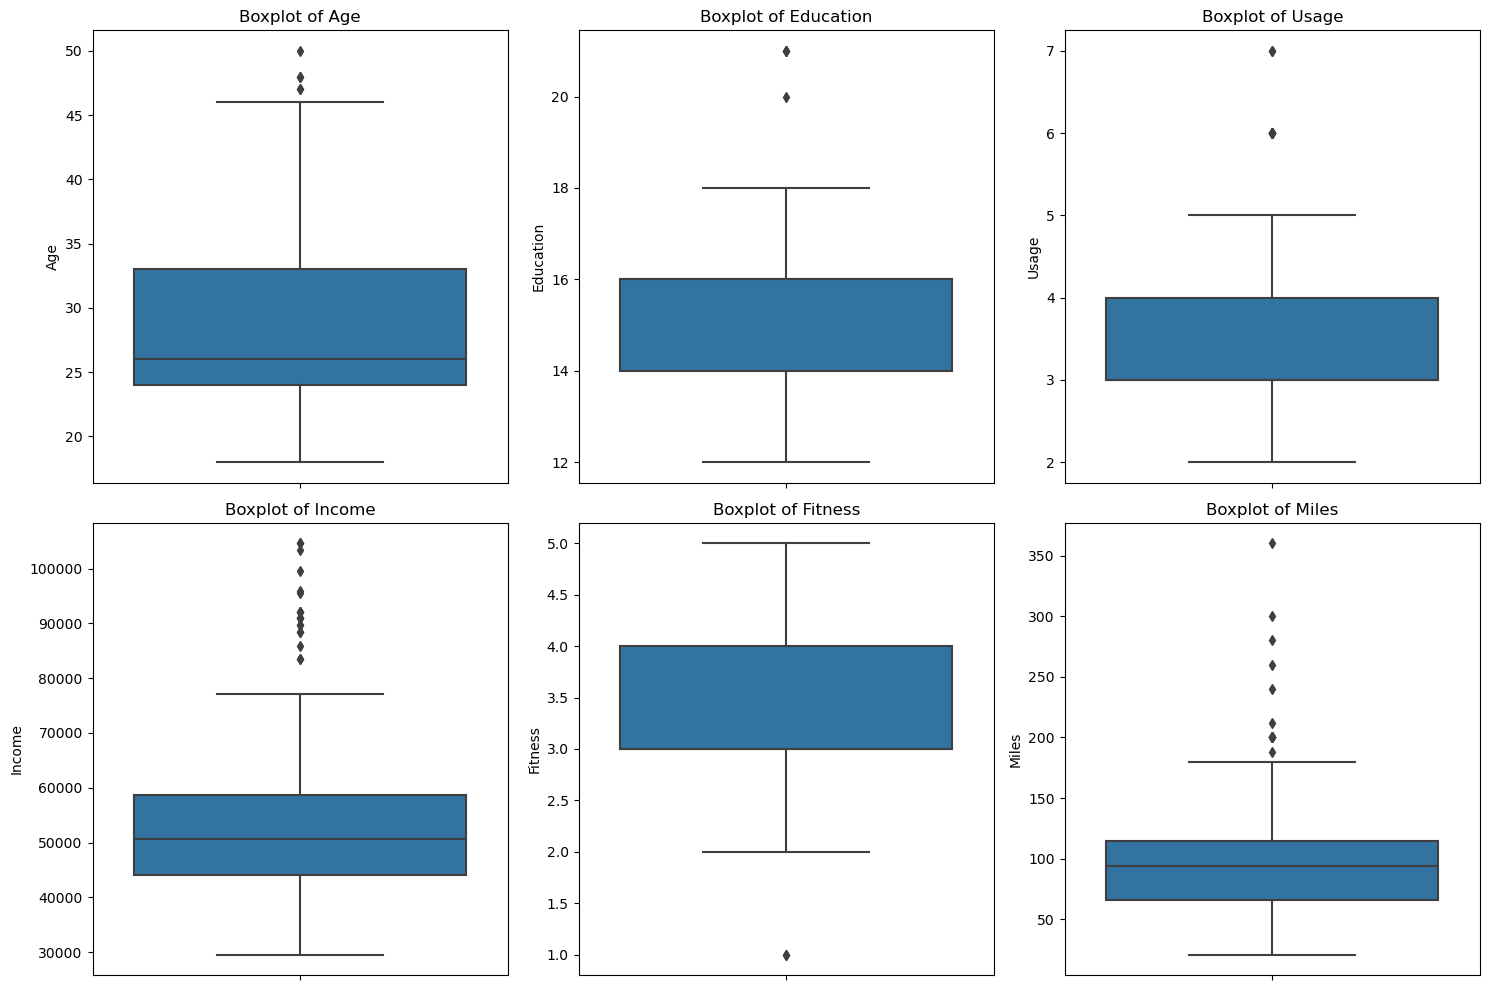

Descriptive Statistics with Mean, Median, and their Difference:
                   mean   median  diff_mean_median
Age           28.788889     26.0          2.788889
Education     15.572222     16.0          0.427778
Usage          3.455556      3.0          0.455556
Income     53719.577778  50596.5       3123.077778
Fitness        3.311111      3.0          0.311111
Miles        103.194444     94.0          9.194444


In [14]:
import matplotlib.pyplot as plt 
import seaborn as sns 

num_cols = ['Age', 'Education', 'Usage', 'Income', 'Fitness', 'Miles']

plt.figure(figsize=(15, 10))
for i, col in enumerate(num_cols, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(y=df[col])
    plt.title(f'Boxplot of {col}')
plt.tight_layout()
plt.show()


desc = df[num_cols].describe().T
desc['median'] = df[num_cols].median()
desc['diff_mean_median'] = abs(desc['mean'] - desc['median'])
print("Descriptive Statistics with Mean, Median, and their Difference:")
print(desc[['mean', 'median', 'diff_mean_median']])

# Outlier Detection and Descriptive Statistics

We performed an outlier analysis using boxplots and compared the mean and median values for our key numerical features. Here’s a summary of our observations:

## 1. Boxplots

The boxplots give a visual representation of the data distribution and highlight potential outliers. Each boxplot displays the interquartile range (IQR), median, and any points lying outside the whiskers (commonly considered potential outliers).

- **Age:**  
  - The majority of customers are between 20 and 35 years old, with a few older customers extending up to 50.
  - No extreme outliers, though a few points are slightly above the upper whisker.

- **Education:**  
  - The data is fairly concentrated between 14 and 16 years of education, indicating a relatively well-educated customer base.
  - Minimal outliers, if any.

- **Usage (times per week):**  
  - The median usage is around 3 times per week, with a few customers using it as many as 7 times weekly.
  - The spread is relatively tight, suggesting most customers have moderate usage levels (2–4 times per week).

- **Income:**  
  - The median annual income is around \$50,596, with a broad range from \$29,562 to \$104,581.
  - Several outliers appear above the upper whisker, indicating a subset of higher-income customers.

- **Fitness (1 to 5 scale):**  
  - The median fitness level is 3, which aligns with moderate self-rated fitness.
  - A few data points extend toward the top end (5), but overall, outliers are minimal.

- **Miles (per week):**  
  - The median weekly miles is around 94, with a wide range up to 360 miles.
  - Outliers on the upper end suggest some highly active individuals in our customer base.

## 2. Descriptive Statistics (Mean vs. Median)

Below is a table showing the mean, median, and the absolute difference between the two for each numerical feature:

| Feature    | Mean     | Median   | diff_mean_median |
|------------|----------|----------|-------------------|
| **Age**    | 28.7889  | 26.0     | 2.7889            |
| **Education** | 15.5722 | 16.0     | 0.4278            |
| **Usage**  | 3.4556   | 3.0      | 0.4556            |
| **Income** | 53719.58 | 50596.50 | 3123.08           |
| **Fitness**| 3.3111   | 3.0      | 0.3111            |
| **Miles**  | 103.1944 | 94.0     | 9.1944            |

### Key Takeaways:

1. **Age:**  
   - The mean is slightly higher than the median, indicating a mild right skew (some older individuals push the average up).
   
2. **Education:**  
   - The mean and median are close, suggesting a relatively symmetric distribution around 15–16 years of education.

3. **Usage:**  
   - The difference between mean (3.46) and median (3.0) is small, indicating that most customers’ usage is fairly concentrated around 3 times per week.

4. **Income:**  
   - There’s a notable gap (\$3,123) between the mean and median, reflecting a right-skewed distribution (a few higher-income customers increase the mean).

5. **Fitness:**  
   - The mean (3.31) is slightly above the median (3.0), indicating a moderate skew. Most customers rate themselves around 3–4 on the fitness scale.

6. **Miles:**  
   - A difference of ~9 miles suggests some right skew, where a subset of very active customers (running more miles) pulls the mean above the median.

## Implications for Stakeholders

- **Product Targeting:**  
  - With higher-income outliers, there is a potential market for premium models (KP781), especially for those who run many miles weekly.
  - The bulk of customers have moderate fitness and usage, suggesting KP281 or KP481 might suit the average buyer.

- **Marketing & Pricing:**  
  - The wide income range supports tiered pricing strategies or financing options to cater to different segments.
  - For the younger segment (median age ~26), digital marketing strategies focusing on affordability and versatility could be effective.

- **Further Analysis:**  
  - These outliers and skewed distributions indicate a need for more detailed segmentation. We can explore whether high-usage and high-income customers consistently prefer advanced treadmills or if they’re distributed across different models.

By understanding where outliers exist and how the distributions are skewed, we can tailor our product offerings and marketing efforts more effectively to match customer needs and behaviors.


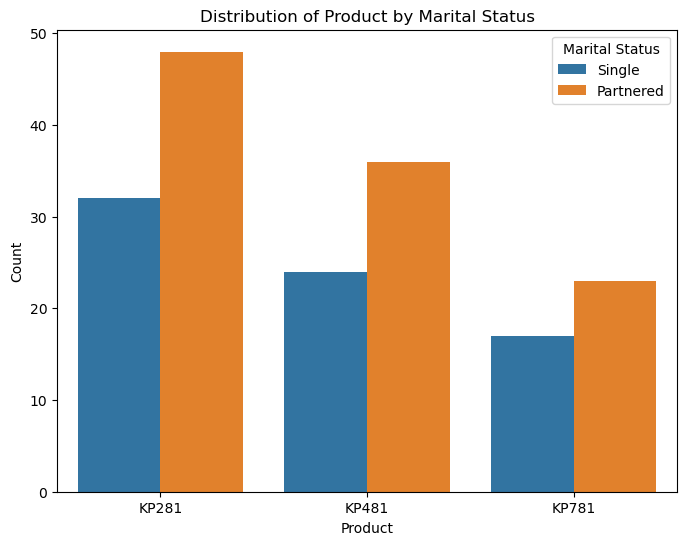

In [17]:

plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='Product', hue='MaritalStatus')
plt.title('Distribution of Product by Marital Status')
plt.xlabel('Product')
plt.ylabel('Count')
plt.legend(title='Marital Status')
plt.show()

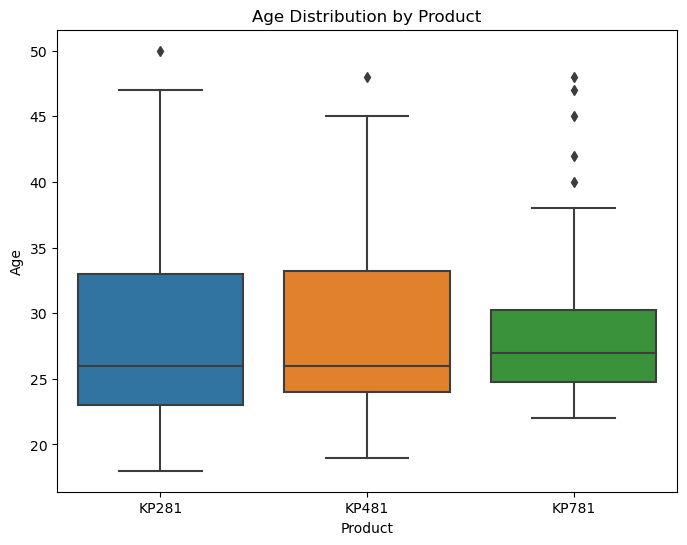

In [18]:

plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x='Product', y='Age')
plt.title('Age Distribution by Product')
plt.xlabel('Product')
plt.ylabel('Age')
plt.show()

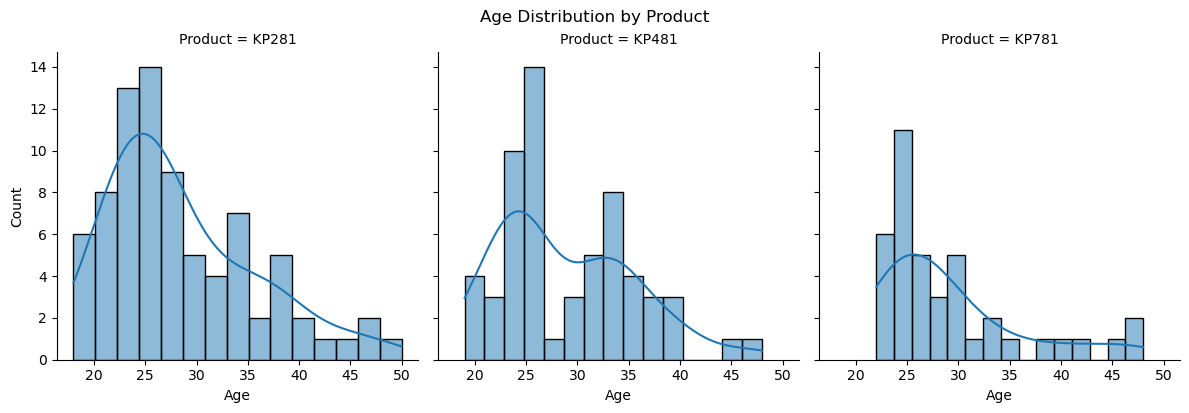

In [19]:

g = sns.FacetGrid(df, col="Product", height=4, aspect=1)
g.map(sns.histplot, "Age", bins=15, kde=True)
g.fig.suptitle('Age Distribution by Product', y=1.02)
plt.show()

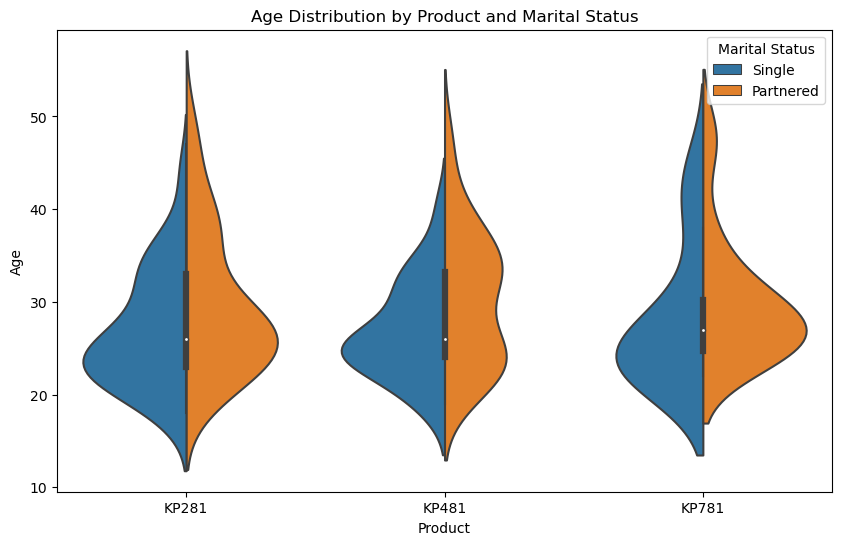

In [20]:

plt.figure(figsize=(10, 6))
sns.violinplot(data=df, x='Product', y='Age', hue='MaritalStatus', split=True)
plt.title('Age Distribution by Product and Marital Status')
plt.xlabel('Product')
plt.ylabel('Age')
plt.legend(title='Marital Status')
plt.show()

# Findings: Product Purchase by Marital Status and Age

Below are key insights derived from our visual analyses, which examined how **Marital Status** and **Age** relate to each product (KP281, KP481, KP781).

---

## 1. Distribution of Product by Marital Status

- **Observation:**  
  - Partnered customers are more prevalent across all products, especially KP281 and KP481.
  - KP281 is the most popular overall, but it still shows a significant share of Single customers.

- **Implication:**  
  - AeroFit may consider targeted marketing for couples or families, especially for KP281 and KP481.
  - Single customers form a substantial portion of the KP281 base, suggesting affordability and entry-level appeal.

---

## 2. Age Distribution by Product (Boxplots & Histograms)

- **KP281:**
  - Appeals to a younger demographic (early-to-mid 20s median).
  - Outliers suggest that some older customers also opt for this entry-level model.
- **KP481:**
  - A slightly higher or broader age range compared to KP281.
  - Some older buyers in their 40s or 50s also choose this model.
- **KP781:**
  - Fewer overall buyers, but they span from mid-20s to late 40s.
  - Notable outliers suggest some older, possibly higher-income, fitness-focused customers.

- **Implication:**  
  - KP281 could be marketed to younger, budget-conscious users.
  - KP481 might require a more generalized approach, highlighting versatility and moderate pricing.
  - KP781 could focus on premium features, attracting higher-income or highly active segments.

---

## 3. Age Distribution by Product and Marital Status (Violin Plots)

- **Observation:**  
  - Partnered customers generally span a broader age range, indicating the potential for dual-income households to invest in mid-range or premium models.
  - Single customers are somewhat concentrated in the 20s for KP281, with a slight presence in KP481.
  - KP781’s distribution, while smaller, includes both younger and older Partnered customers, pointing to a niche but diverse user group.

- **Implication:**  
  - Consider family/couple-focused promotions or financing options, especially for KP481 and KP781.
  - Singles may prefer KP281 for affordability, but some may still choose premium models if they value advanced features.

---

## Overall Strategic Takeaways

1. **Marketing Strategies:**
   - **KP281:** Highlight cost-effectiveness and basic features to appeal to a younger demographic, including single customers starting their fitness journey.
   - **KP481:** Emphasize balanced performance and versatility, suitable for a wide age range and potentially couples who want a mid-range option.
   - **KP781:** Position as a premium product with advanced features, targeting higher-income or highly motivated fitness enthusiasts (both Single and Partnered).

2. **Product Development & Bundling:**
   - Offer couples or family-oriented deals, especially for mid-range and premium treadmills, given the notable share of Partnered buyers.
   - Provide flexible financing options for younger singles who may be budget-conscious but still interested in quality or advanced features.



In [22]:

product_marginals = pd.crosstab(df['Product'], columns='Count', normalize='all') * 100

product_marginals.columns = ['Percentage (%)']

print("Marginal Probability of Product Purchased:")
print(product_marginals)

Marginal Probability of Product Purchased:
         Percentage (%)
Product                
KP281         44.444444
KP481         33.333333
KP781         22.222222


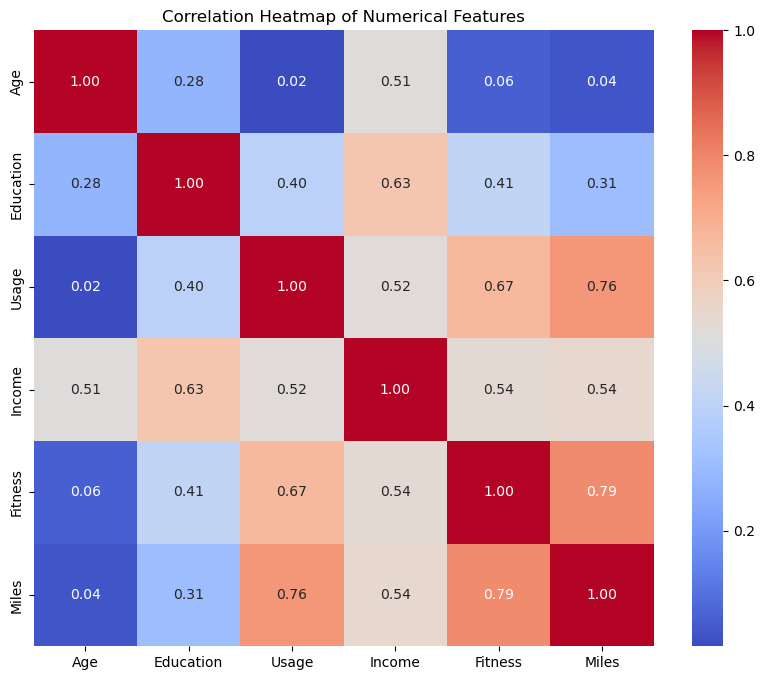

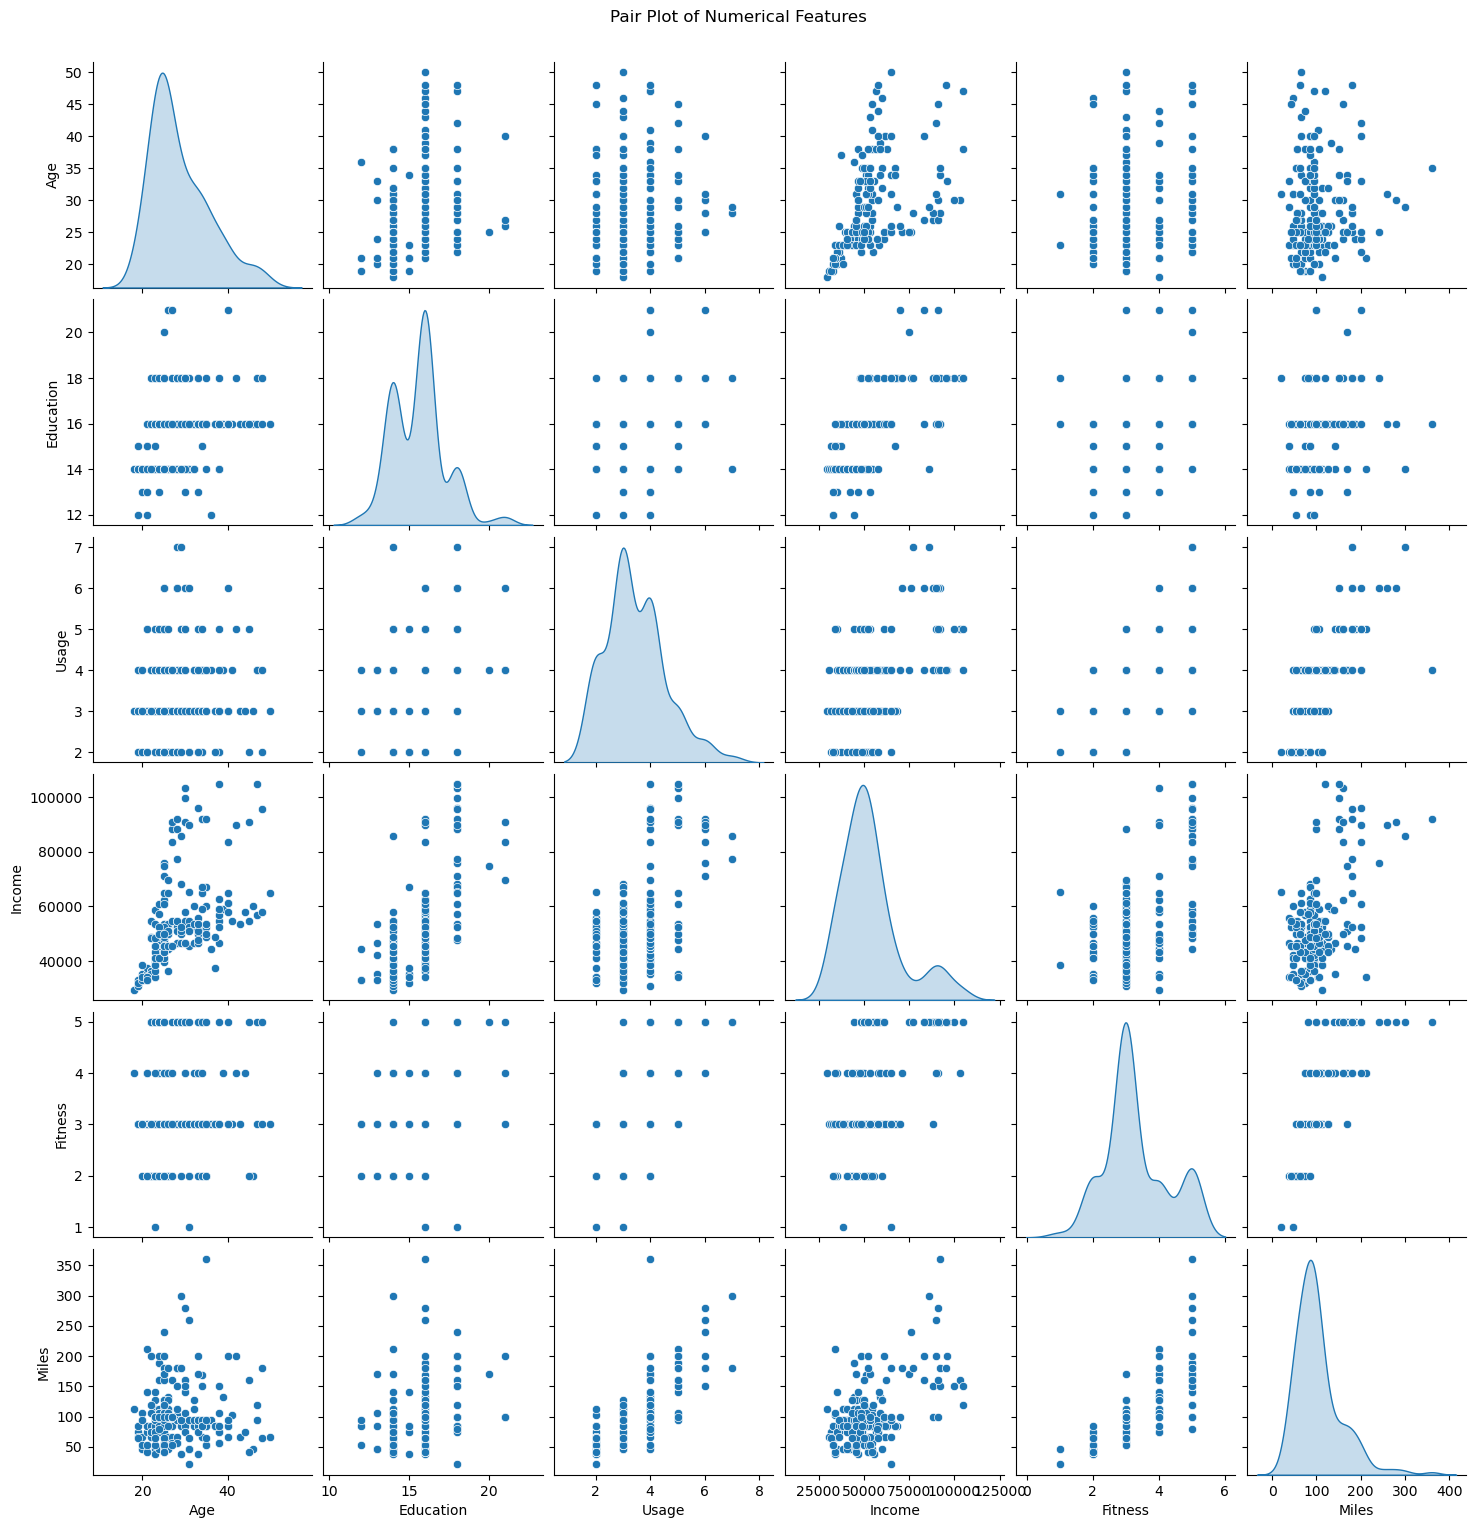

In [23]:

numerical_features = ['Age', 'Education', 'Usage', 'Income', 'Fitness', 'Miles']

corr_matrix = df[numerical_features].corr()


plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of Numerical Features')
plt.show()


sns.pairplot(df[numerical_features], diag_kind='kde') 
plt.suptitle('Pair Plot of Numerical Features', y=1.02)
plt.show()

# Observations from Correlation Heatmap and Pair Plot

1. **Usage & Miles**  
   - **Highest positive correlation (0.76)**. Customers who plan to use the treadmill more frequently also expect to cover more miles each week.

2. **Fitness & Miles**  
   - **Strong correlation (0.79)**. Higher self-rated fitness is closely associated with walking or running more miles.

3. **Usage & Fitness**  
   - **Moderately high correlation (0.67)**. Frequent treadmill use often corresponds to a higher fitness level.

4. **Income & Education**  
   - **Moderate correlation (0.63)**. Individuals with more years of education tend to have higher annual incomes.

5. **Age & Income**  
   - **Moderate correlation (0.51)**. Older customers generally report higher incomes.

6. **Scatter Plot Trends**  
   - **Usage vs. Miles** and **Fitness vs. Miles** show clear upward trends, consistent with their strong correlations.  
   - **Age vs. Income** also slopes upward, indicating older individuals often earn more, though the relationship is less pronounced.

7. **Distribution Insights**  
   - **Age** and **Income** are slightly skewed, with a subset of older and higher-earning customers.  
   - **Miles** shows a wide range, from casual walkers to highly active runners.

These observations suggest that frequent usage and high fitness levels are closely linked, while income correlates with age and education. Such insights can guide more nuanced marketing strategies and product recommendations, targeting both highly active users and higher-income segments.


In [25]:

male_customers = df[df['Gender'] == 'Male']


total_males = male_customers.shape[0]


male_KP781 = male_customers[male_customers['Product'] == 'KP781'].shape[0]


probability_KP781_given_male = male_KP781 / total_males

print("Probability of a male customer buying a KP781 treadmill:", probability_KP781_given_male)

Probability of a male customer buying a KP781 treadmill: 0.3173076923076923


/Users/nikhil/anaconda3/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
/Users/nikhil/anaconda3/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
/Users/nikhil/anaconda3/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
/Users/nikhil/anaconda3/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:1412: FutureWarning: The default value of `n_init` will change fr

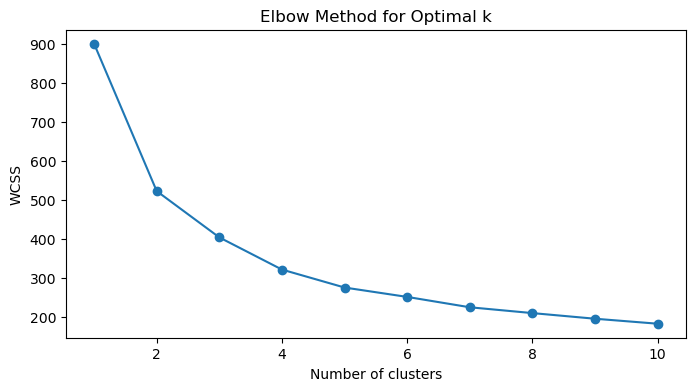

/Users/nikhil/anaconda3/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


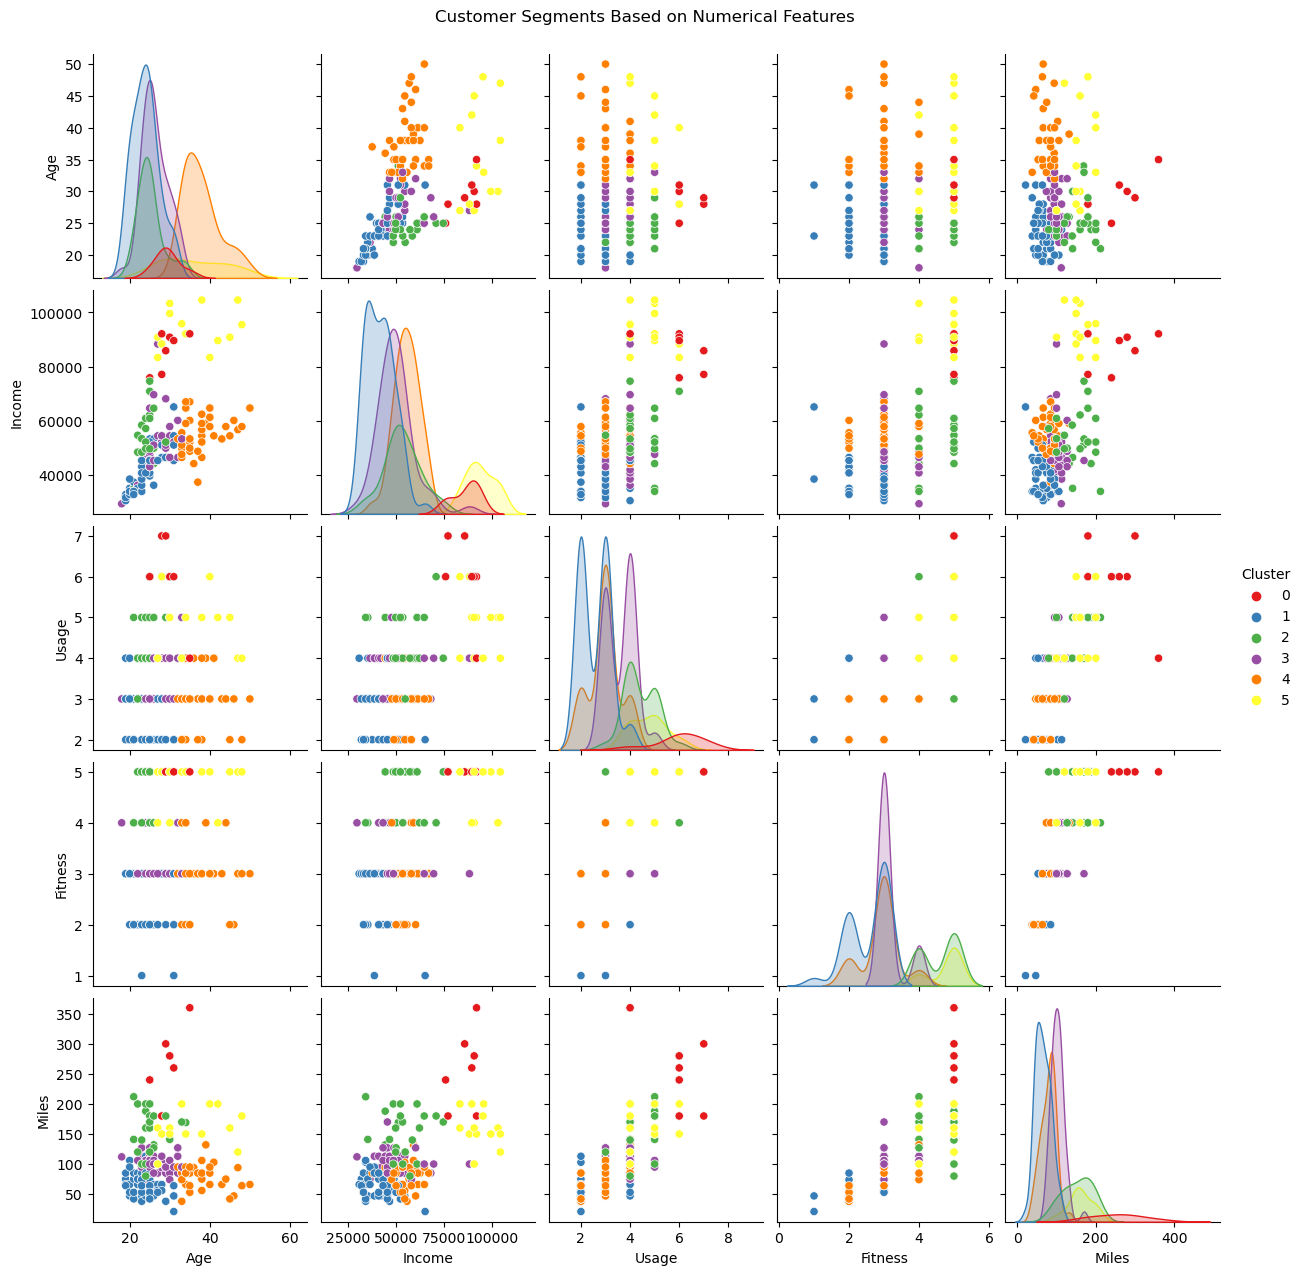

Cluster Centers (Original Scale):
         Age        Income     Usage   Fitness       Miles
0  29.428571  86261.714286  6.000000  5.000000  257.142857
1  23.981132  41690.603774  2.584906  2.566038   65.396226
2  25.166667  53306.750000  4.416667  4.583333  152.916667
3  26.204545  49841.954545  3.613636  3.159091  102.045455
4  37.923077  55421.461538  2.974359  2.923077   78.692308
5  36.076923  94018.846154  4.769231  4.769231  160.000000


In [28]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler


features = ['Age', 'Income', 'Usage', 'Fitness', 'Miles']
X = df[features]


scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


wcss = []  
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(range(1, 11), wcss, marker='o')
plt.title('Elbow Method for Optimal k')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()


optimal_k = 6
kmeans = KMeans(n_clusters=optimal_k, random_state=42)
df['Cluster'] = kmeans.fit_predict(X_scaled)


sns.pairplot(df, vars=features, hue='Cluster', palette='Set1', diag_kind='kde')
plt.suptitle('Customer Segments Based on Numerical Features', y=1.02)
plt.show()


centers_scaled = kmeans.cluster_centers_
centers = scaler.inverse_transform(centers_scaled)
centers_df = pd.DataFrame(centers, columns=features)
print("Cluster Centers (Original Scale):")
print(centers_df)

# Findings from Cluster Analysis

Based on the **pair plot** and the **cluster centers** shown above, we identified **6 distinct customer segments**. Below is a brief interpretation of each cluster’s center (in original scale):

| Cluster | Age (avg) | Income (avg) | Usage (avg) | Fitness (avg) | Miles (avg) | Potential Label                                         |
|---------|-----------|--------------|-------------|---------------|-------------|---------------------------------------------------------|
| **0**   | ~29.4     | \$86,262     | 6.0         | 5.0           | 257.1       | **High-Income, High-Usage Enthusiasts**                |
| **1**   | ~24.0     | \$41,691     | 2.58        | 2.57          | 65.4        | **Young, Budget-Conscious Novices**                    |
| **2**   | ~25.2     | \$53,307     | 4.42        | 4.58          | 152.9       | **Young, Fit, Moderate-Income Users**                  |
| **3**   | ~26.2     | \$49,842     | 3.61        | 3.16          | 102.0       | **Moderate Age, Moderate Usage & Income**              |
| **4**   | ~37.9     | \$55,421     | 2.97        | 2.92          | 78.7        | **Older, Mid-Income, Lower Usage**                     |
| **5**   | ~36.1     | \$94,019     | 4.77        | 4.77          | 160.0       | **Older, High-Income, High-Fitness Users**             |

---

## 1. Cluster 0: High-Income, High-Usage Enthusiasts
- **Profile:** Relatively younger (late 20s), very high income, frequent treadmill usage (6 times/week), top-tier fitness rating (5), and extremely high weekly mileage (~257 miles).
- **Insight:** This group likely represents very active individuals who can afford premium models (KP781) and might value advanced features or coaching programs.

## 2. Cluster 1: Young, Budget-Conscious Novices
- **Profile:** Early 20s, lower income, low-to-moderate usage (~2.6), lower fitness (~2.6), and lower mileage (~65).
- **Insight:** Entry-level users possibly just starting their fitness journey. Affordable pricing and beginner-friendly features may resonate with them (e.g., KP281).

## 3. Cluster 2: Young, Fit, Moderate-Income Users
- **Profile:** Mid-20s, moderate income, higher treadmill usage (~4.4), near-top fitness rating (~4.6), and high mileage (~153).
- **Insight:** Active, fitness-oriented segment but not at the highest income bracket. They may be interested in mid-range to premium treadmills (KP481 or KP781), especially if financing or special offers are available.

## 4. Cluster 3: Moderate Age, Moderate Usage & Income
- **Profile:** Mid-to-late 20s, around \$50K income, moderate usage (~3.6), moderate fitness (~3.2), and weekly mileage (~102).
- **Insight:** A balanced, “average” segment likely to respond well to versatile mid-range products (KP481) and standard workout programs.

## 5. Cluster 4: Older, Mid-Income, Lower Usage
- **Profile:** Late 30s, mid-income (~\$55K), lower usage (~3), moderate fitness (~2.9), and fewer miles (~79).
- **Insight:** Possibly busier lifestyles or less emphasis on intense workouts. Emphasizing convenience, health benefits, and easy-to-use features could appeal to this segment.

## 6. Cluster 5: Older, High-Income, High-Fitness Users
- **Profile:** Mid-to-late 30s, high income (~\$94K), frequent usage (~4.8), high fitness (~4.8), and high mileage (~160).
- **Insight:** Similar to Cluster 0 in terms of high activity and willingness to invest, but slightly older. Premium models with advanced training features or extended warranties might be key selling points.

---

## Overall Interpretation

- **Premium Segments (Clusters 0 & 5):**  
  High earners with strong fitness and high usage/mileage. Ideal audience for **KP781** or advanced features.

- **Mid-Range & Versatile (Clusters 2 & 3):**  
  Younger to mid-aged customers with moderate-to-high usage and fitness but not top-tier incomes. They might balance cost and features, potentially favoring **KP481**.

- **Entry-Level / Budget (Cluster 1):**  
  Young, lower income, and lower fitness. Likely to respond well to **KP281** promotions or financing plans.

- **Lower Usage, Older (Cluster 4):**  
  Older individuals with moderate income and less frequent usage. Messaging around health maintenance, comfort, and ease-of-use could be more effective than performance-driven marketing.

By aligning marketing strategies and product offerings with these distinct customer profiles, AeroFit can optimize customer satisfaction, improve sales, and foster brand loyalty across multiple segments.


In [30]:

marginal_product = pd.crosstab(index=df['Product'], columns='count', normalize=True) * 100
marginal_product.columns = ['Percentage (%)']

print("Marginal Probability of Product Purchased:")
print(marginal_product)
print("\n")




conditional_product_gender = pd.crosstab(index=df['Gender'], columns=df['Product'], normalize='index') * 100

print("Conditional Probability of Product Purchased given Gender (in %):")
print(conditional_product_gender)
print("\n")


male_conditional = conditional_product_gender.loc['Male', 'KP781']
print("Probability of a male customer buying a KP781 treadmill: {:.2f}%".format(male_conditional))

Marginal Probability of Product Purchased:
         Percentage (%)
Product                
KP281         44.444444
KP481         33.333333
KP781         22.222222


Conditional Probability of Product Purchased given Gender (in %):
Product      KP281      KP481      KP781
Gender                                  
Female   52.631579  38.157895   9.210526
Male     38.461538  29.807692  31.730769


Probability of a male customer buying a KP781 treadmill: 31.73%


# Key Findings: Product Purchase Probabilities

1. **Marginal Probability of Product Purchased**  
   - **KP281:** 44.44%  
   - **KP481:** 33.33%  
   - **KP781:** 22.22%  

   **Interpretation:**  
   - Out of all treadmill purchases, nearly **44%** are KP281, making it the most popular model overall.  
   - KP481 accounts for about **33%** of purchases.  
   - KP781, the advanced model, comprises roughly **22%** of total sales.

2. **Conditional Probability by Gender**  
   **Female Customers:**  
   - **KP281:** 52.63%  
   - **KP481:** 38.16%  
   - **KP781:** 9.21%  

   **Male Customers:**  
   - **KP281:** 38.46%  
   - **KP481:** 29.81%  
   - **KP781:** 31.73%  

   **Interpretation:**  
   - Among **female** buyers, **over half (52.63%)** choose KP281, while only **9.21%** opt for KP781. This suggests KP281 resonates strongly with female customers, possibly due to price point, features, or marketing appeals.  
   - Among **male** buyers, KP281 still holds a significant share (38.46%), but **nearly a third (31.73%)** choose KP781, indicating a greater inclination among male customers to invest in the advanced model.

3. **Example: Probability of a Male Customer Buying KP781**  
   - **31.73%**  
   - In other words, roughly **1 in 3** male customers end up purchasing the KP781 treadmill.

---

## Strategic Implications

- **KP281’s Popularity:**  
  - As the most frequently purchased model (44.44%), KP281 might be perceived as a balanced or budget-friendly option. Consider highlighting cost-effectiveness or ease-of-use in marketing materials.

- **Gender-Specific Insights:**
  - **Female Segment:** Strong preference for KP281 (over 50%). Promotions focusing on simplicity, value, or comfort may be particularly effective.  
  - **Male Segment:** KP781’s popularity (nearly 32%) indicates a higher willingness to invest in premium features. Highlight advanced technology, performance, or durability to attract more male buyers.

- **Opportunity to Upsell:**  
  - Given that 31.73% of male customers choose the high-end model, there is a potential upsell opportunity for the remaining 68% who currently opt for KP281 or KP481. Targeted marketing or in-store demos could encourage customers to upgrade.

- **Product Portfolio Positioning:**  
  - **KP281:** Market as an affordable, entry-level treadmill appealing to a broad audience (especially females).  
  - **KP481:** Continue to position as a mid-range option for those wanting balanced features without the premium price.  
  - **KP781:** Emphasize cutting-edge features and high-performance capabilities to attract male customers and serious fitness enthusiasts.

By using these probabilities to guide marketing and sales strategies, AeroFit can more effectively match customers to the treadmill that best suits their needs and maximize overall revenue.


# Recommendations for AeroFit

Based on our analysis, recommendations to drive business growth:

1. **Tailor Product Messaging:**  
   - Market KP281 as an affordable, entry-level option ideal for first-time buyers.
   - Position KP481 as a balanced, mid-range model with versatile features.
   - Promote KP781 as a premium treadmill with advanced features for serious fitness enthusiasts.

2. **Targeted Advertising by Gender:**  
   - Develop ads for female customers that emphasize the value and simplicity of KP281.
   - Create campaigns for male customers that highlight the advanced technology and performance of KP781.

3. **Upsell Opportunities:**  
   - Implement in-store demos and targeted marketing to encourage male customers who bought KP281 or KP481 to upgrade to KP781.

4. **Family and Couple Promotions:**  
   - Offer special packages or discounts for partnered customers, especially for mid-range and premium models.

5. **Flexible Financing Options:**  
   - Introduce financing or installment plans to make higher-end models more accessible for budget-conscious buyers.

6. **Digital Marketing Focus:**  
   - Use social media and digital channels to reach the average customer (late 20s), emphasizing modern design and technology.

7. **Loyalty Programs:**  
   - Create rewards or loyalty programs to encourage repeat purchases and referrals from satisfied customers.

8. **Enhanced Customer Support:**  
   - Offer after-sales services such as extended warranties and personalized training tips to boost customer satisfaction.

9. **Bundled Value-Added Services:**  
   - Bundle products with additional services (e.g., fitness coaching, maintenance plans) to add extra value, especially for premium models.

10. **Continuous Customer Feedback:**  
    - Regularly collect customer feedback to refine product features and ensure marketing messages meet evolving customer needs.

These recommendations aim to align AeroFit’s offerings with the distinct needs and preferences of its customer segments, thereby increasing sales, customer satisfaction, and overall brand loyalty.
